# 02 — Feature Engineering

This notebook calculates spectral indices and SAR features from the preprocessed Sentinel-2 and Sentinel-1 imagery. The output is a single feature stack per epoch — a multi-band array where every pixel has 20 features describing its spectral, structural, and textural properties.

These feature stacks are what the machine learning models in notebook 04 will train on.

**Inputs:** Processed GeoTIFFs from GEOL0069/Project/Data/Processed  
**Outputs:** Feature stack GeoTIFFs saved to GEOL0069/Project/Data/Features

**Features calculated:**
- Spectral indices: NDVI, NDWI, NDBI, BSI, EVI
- Raw bands: B2, B3, B4, B8, B11
- SAR: VV, VH, VH/VV ratio
- Texture: GLCM contrast and homogeneity on NIR band

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
!pip install rasterio scikit-image --quiet

import numpy as np
import rasterio
from rasterio.transform import from_bounds
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
from skimage.feature import graycomatrix, graycoprops
import os
import warnings
warnings.filterwarnings('ignore')

print("Libraries loaded successfully")

Libraries loaded successfully


In [3]:
# File paths
processed_path = '/content/drive/MyDrive/GEOL0069/Project/Data/Processed'
features_path  = '/content/drive/MyDrive/GEOL0069/Project/Data/Features'

os.makedirs(features_path, exist_ok=True)

epochs = ['2019', '2021', '2023', '2025']

print(f"Processed data: {processed_path}")
print(f"Features output: {features_path}")




Processed data: /content/drive/MyDrive/GEOL0069/Project/Data/Processed
Features output: /content/drive/MyDrive/GEOL0069/Project/Data/Features


Our Sentinel-2 files have 10 bands in this order (as exported from GEE):
B2, B3, B4, B5, B6, B7, B8, B8A, B11, B12

We name them clearly so the index calculations below are readable.

In [4]:
def load_s2_bands(epoch):
    """
    Loads all 10 Sentinel-2 bands for a given epoch.
    Returns a dictionary of named band arrays and the rasterio metadata.
    """
    filepath = os.path.join(processed_path, f'S2_{epoch}_10m.tif')

    with rasterio.open(filepath) as src:
        meta = src.meta.copy()
        bands = {
            'B2':  src.read(1).astype('float32'),   # Blue
            'B3':  src.read(2).astype('float32'),   # Green
            'B4':  src.read(3).astype('float32'),   # Red
            'B5':  src.read(4).astype('float32'),   # Red Edge 1
            'B6':  src.read(5).astype('float32'),   # Red Edge 2
            'B7':  src.read(6).astype('float32'),   # Red Edge 3
            'B8':  src.read(7).astype('float32'),   # NIR
            'B8A': src.read(8).astype('float32'),   # Narrow NIR
            'B11': src.read(9).astype('float32'),   # SWIR 1
            'B12': src.read(10).astype('float32'),  # SWIR 2
        }

    return bands, meta


def load_s1_bands(epoch):
    """
    Loads VV and VH bands from the processed Sentinel-1 file.
    """
    filepath = os.path.join(processed_path, f'S1_{epoch}_processed.tif')

    with rasterio.open(filepath) as src:
        vv = src.read(1).astype('float32')
        vh = src.read(2).astype('float32')

    return vv, vh

print("Band loading functions defined")

Band loading functions defined


## Step 2 — Spectral index functions

Each function takes the named band arrays and returns a 2D index array. Division is handled safely — where the denominator is zero we return zero rather than NaN, which would cause problems in the models later.

- **NDVI:** Normalised Difference Vegetation Index — high values = healthy vegetation, low = bare soil or built surfaces
- **NDWI:** Normalised Difference Water Index — positive values = open water
- **NDBI:** Normalised Difference Built-up Index — positive values = built-up surfaces
- **BSI:** Bare Soil Index — high values = exposed bare soil
- **EVI:** Enhanced Vegetation Index — like NDVI but less sensitive to atmospheric effects and soil background

In [5]:
def safe_divide(a, b):
    """Divides a by b, returning 0 where b is zero to avoid NaN values."""
    return np.where(b != 0, a / b, 0)


def calc_ndvi(bands):
    """NDVI = (NIR - Red) / (NIR + Red)"""
    nir = bands['B8']
    red = bands['B4']
    return safe_divide(nir - red, nir + red)


def calc_ndwi(bands):
    """NDWI = (Green - NIR) / (Green + NIR)"""
    green = bands['B3']
    nir   = bands['B8']
    return safe_divide(green - nir, green + nir)

#NDBI CALCULATION

def calc_ndbi(bands):
    """NDBI = (SWIR1 - NIR) / (SWIR1 + NIR)"""
    swir = bands['B11']
    nir  = bands['B8']
    return safe_divide(swir - nir, swir + nir)


def calc_bsi(bands):
    """BSI = ((SWIR1 + Red) - (NIR + Blue)) / ((SWIR1 + Red) + (NIR + Blue))"""
    swir = bands['B11']
    red  = bands['B4']
    nir  = bands['B8']
    blue = bands['B2']
    numerator   = (swir + red) - (nir + blue)
    denominator = (swir + red) + (nir + blue)
    return safe_divide(numerator, denominator)


def calc_evi(bands):
    """EVI = 2.5 * (NIR - Red) / (NIR + 6*Red - 7.5*Blue + 1)"""
    nir  = bands['B8']
    red  = bands['B4']
    blue = bands['B2']
    numerator   = 2.5 * (nir - red)
    denominator = nir + 6 * red - 7.5 * blue + 1
    return safe_divide(numerator, denominator)


print("Spectral index functions defined")

Spectral index functions defined


## Step 3 — GLCM texture features

The Grey Level Co-occurrence Matrix (GLCM) captures texture — how pixel values vary relative to their neighbours. This is particularly useful for distinguishing urban surfaces (which look rough and irregular at 10m resolution) from cropland (which looks smooth and uniform).

We calculate two GLCM properties on the NIR band (B8):
- **Contrast:** measures local intensity variation — high in urban areas, low in uniform fields
- **Homogeneity:** measures how similar neighbouring pixels are — high in uniform areas like water or large fields

Because GLCM is slow to compute on a full image, we use a sliding window approach on a downsampled version and resize back up.

In [6]:
def calc_glcm_features(nir_band, window_size=7):
    """
    Calculates GLCM contrast and homogeneity on the NIR band
    using a sliding window approach.

    To keep computation time reasonable we process every 3rd pixel
    and interpolate the gaps.
    """
    from skimage.util import view_as_windows
    from scipy.ndimage import zoom

    h, w = nir_band.shape

    # Normalise NIR to 0-63 range for GLCM (reduces compute time vs 0-255)
    nir_norm = nir_band.copy()
    nir_valid = nir_norm[nir_norm > 0]
    if len(nir_valid) > 0:
        nir_norm = np.clip(nir_norm, 0, np.percentile(nir_valid, 99))
        nir_norm = ((nir_norm / nir_norm.max()) * 63).astype(np.uint8)

    # Subsample for speed — compute on every 5th pixel then resize
    step = 5
    contrast_small    = np.zeros((h // step, w // step), dtype='float32')
    homogeneity_small = np.zeros((h // step, w // step), dtype='float32')

    half = window_size // 2

    for i in range(h // step):
        for j in range(w // step):
            pi = min(i * step + half, h - window_size)
            pj = min(j * step + half, w - window_size)
            patch = nir_norm[pi:pi+window_size, pj:pj+window_size]

            if patch.shape == (window_size, window_size):
                glcm = graycomatrix(patch, distances=[1], angles=[0],
                                    levels=64, symmetric=True, normed=True)
                contrast_small[i, j]    = graycoprops(glcm, 'contrast')[0, 0]
                homogeneity_small[i, j] = graycoprops(glcm, 'homogeneity')[0, 0]

    # Resize back to original dimensions
    scale_h = h / contrast_small.shape[0]
    scale_w = w / contrast_small.shape[1]
    contrast    = zoom(contrast_small,    (scale_h, scale_w), order=1)
    homogeneity = zoom(homogeneity_small, (scale_h, scale_w), order=1)

    return contrast.astype('float32'), homogeneity.astype('float32')

print("GLCM texture function defined")
print("Note: GLCM calculation takes 3-5 minutes per epoch — this is normal")

GLCM texture function defined
Note: GLCM calculation takes 3-5 minutes per epoch — this is normal


For each epoch we combine all features into a single array with shape (20, height, width). Each of the 20 layers represents one feature. This is saved as a GeoTIFF so it can be loaded directly in the modelling notebook.


In [7]:
# ALL 15 FEATURES
def build_feature_stack(epoch):
    """
    Builds the full 20-feature stack for one epoch and saves it as a GeoTIFF.

    Feature order:
    0:  NDVI
    1:  NDWI
    2:  NDBI
    3:  BSI
    4:  EVI
    5:  B2 (Blue)
    6:  B3 (Green)
    7:  B4 (Red)
    8:  B8 (NIR)
    9:  B11 (SWIR1)
    10: VV (SAR)
    11: VH (SAR)
    12: VH/VV ratio
    13: GLCM contrast
    14: GLCM homogeneity
    """
    print(f"\nProcessing epoch: {epoch}")

    # Load raw bands
    print("  Loading bands...")
    bands, meta = load_s2_bands(epoch)
    vv, vh = load_s1_bands(epoch)

    # Calculate spectral indices
    print("  Calculating spectral indices...")
    ndvi = calc_ndvi(bands)
    ndwi = calc_ndwi(bands)
    ndbi = calc_ndbi(bands)
    bsi  = calc_bsi(bands)
    evi  = calc_evi(bands)

    # SAR ratio
    print("  Calculating SAR features...")
    vv_vh_ratio = safe_divide(vh, vv)

    # GLCM texture (slowest step)
    print("  Calculating GLCM texture (this takes a few minutes)...")
    contrast, homogeneity = calc_glcm_features(bands['B8'])

    # Stack all features into one array: shape (15, H, W)
    print("  Stacking features...")
    feature_stack = np.stack([
        ndvi,
        ndwi,
        ndbi,
        bsi,
        evi,
        bands['B2'],
        bands['B3'],
        bands['B4'],
        bands['B8'],
        bands['B11'],
        vv,
        vh,
        vv_vh_ratio,
        contrast,
        homogeneity
    ], axis=0)

    # Clip extreme values that could destabilise training
    feature_stack = np.clip(feature_stack, -5, 5)

    # Save as GeoTIFF
    output_path = os.path.join(features_path, f'features_{epoch}.tif')

    out_meta = meta.copy()
    out_meta.update({
        'count': feature_stack.shape[0],
        'dtype': 'float32'
    })

    with rasterio.open(output_path, 'w', **out_meta) as dst:
        dst.write(feature_stack)

    print(f"  Saved: features_{epoch}.tif — shape {feature_stack.shape}")
    return feature_stack


# Run for all epochs
feature_stacks = {}
for epoch in epochs:
    feature_stacks[epoch] = build_feature_stack(epoch)

print("\nAll feature stacks complete")


Processing epoch: 2019
  Loading bands...
  Calculating spectral indices...
  Calculating SAR features...
  Calculating GLCM texture (this takes a few minutes)...
  Stacking features...
  Saved: features_2019.tif — shape (15, 3465, 3212)

Processing epoch: 2021
  Loading bands...
  Calculating spectral indices...
  Calculating SAR features...
  Calculating GLCM texture (this takes a few minutes)...
  Stacking features...
  Saved: features_2021.tif — shape (15, 3465, 3212)

Processing epoch: 2023
  Loading bands...
  Calculating spectral indices...
  Calculating SAR features...
  Calculating GLCM texture (this takes a few minutes)...
  Stacking features...
  Saved: features_2023.tif — shape (15, 3465, 3212)

Processing epoch: 2025
  Loading bands...
  Calculating spectral indices...
  Calculating SAR features...
  Calculating GLCM texture (this takes a few minutes)...
  Stacking features...
  Saved: features_2025.tif — shape (15, 3465, 3212)

All feature stacks complete


**Five Index Functions Together**

Plotting the five spectral indices for all four epochs so we can visually verify they look sensible. This is also the kind of figure that goes well in your GitHub README or project report — it shows what each index is actually detecting.


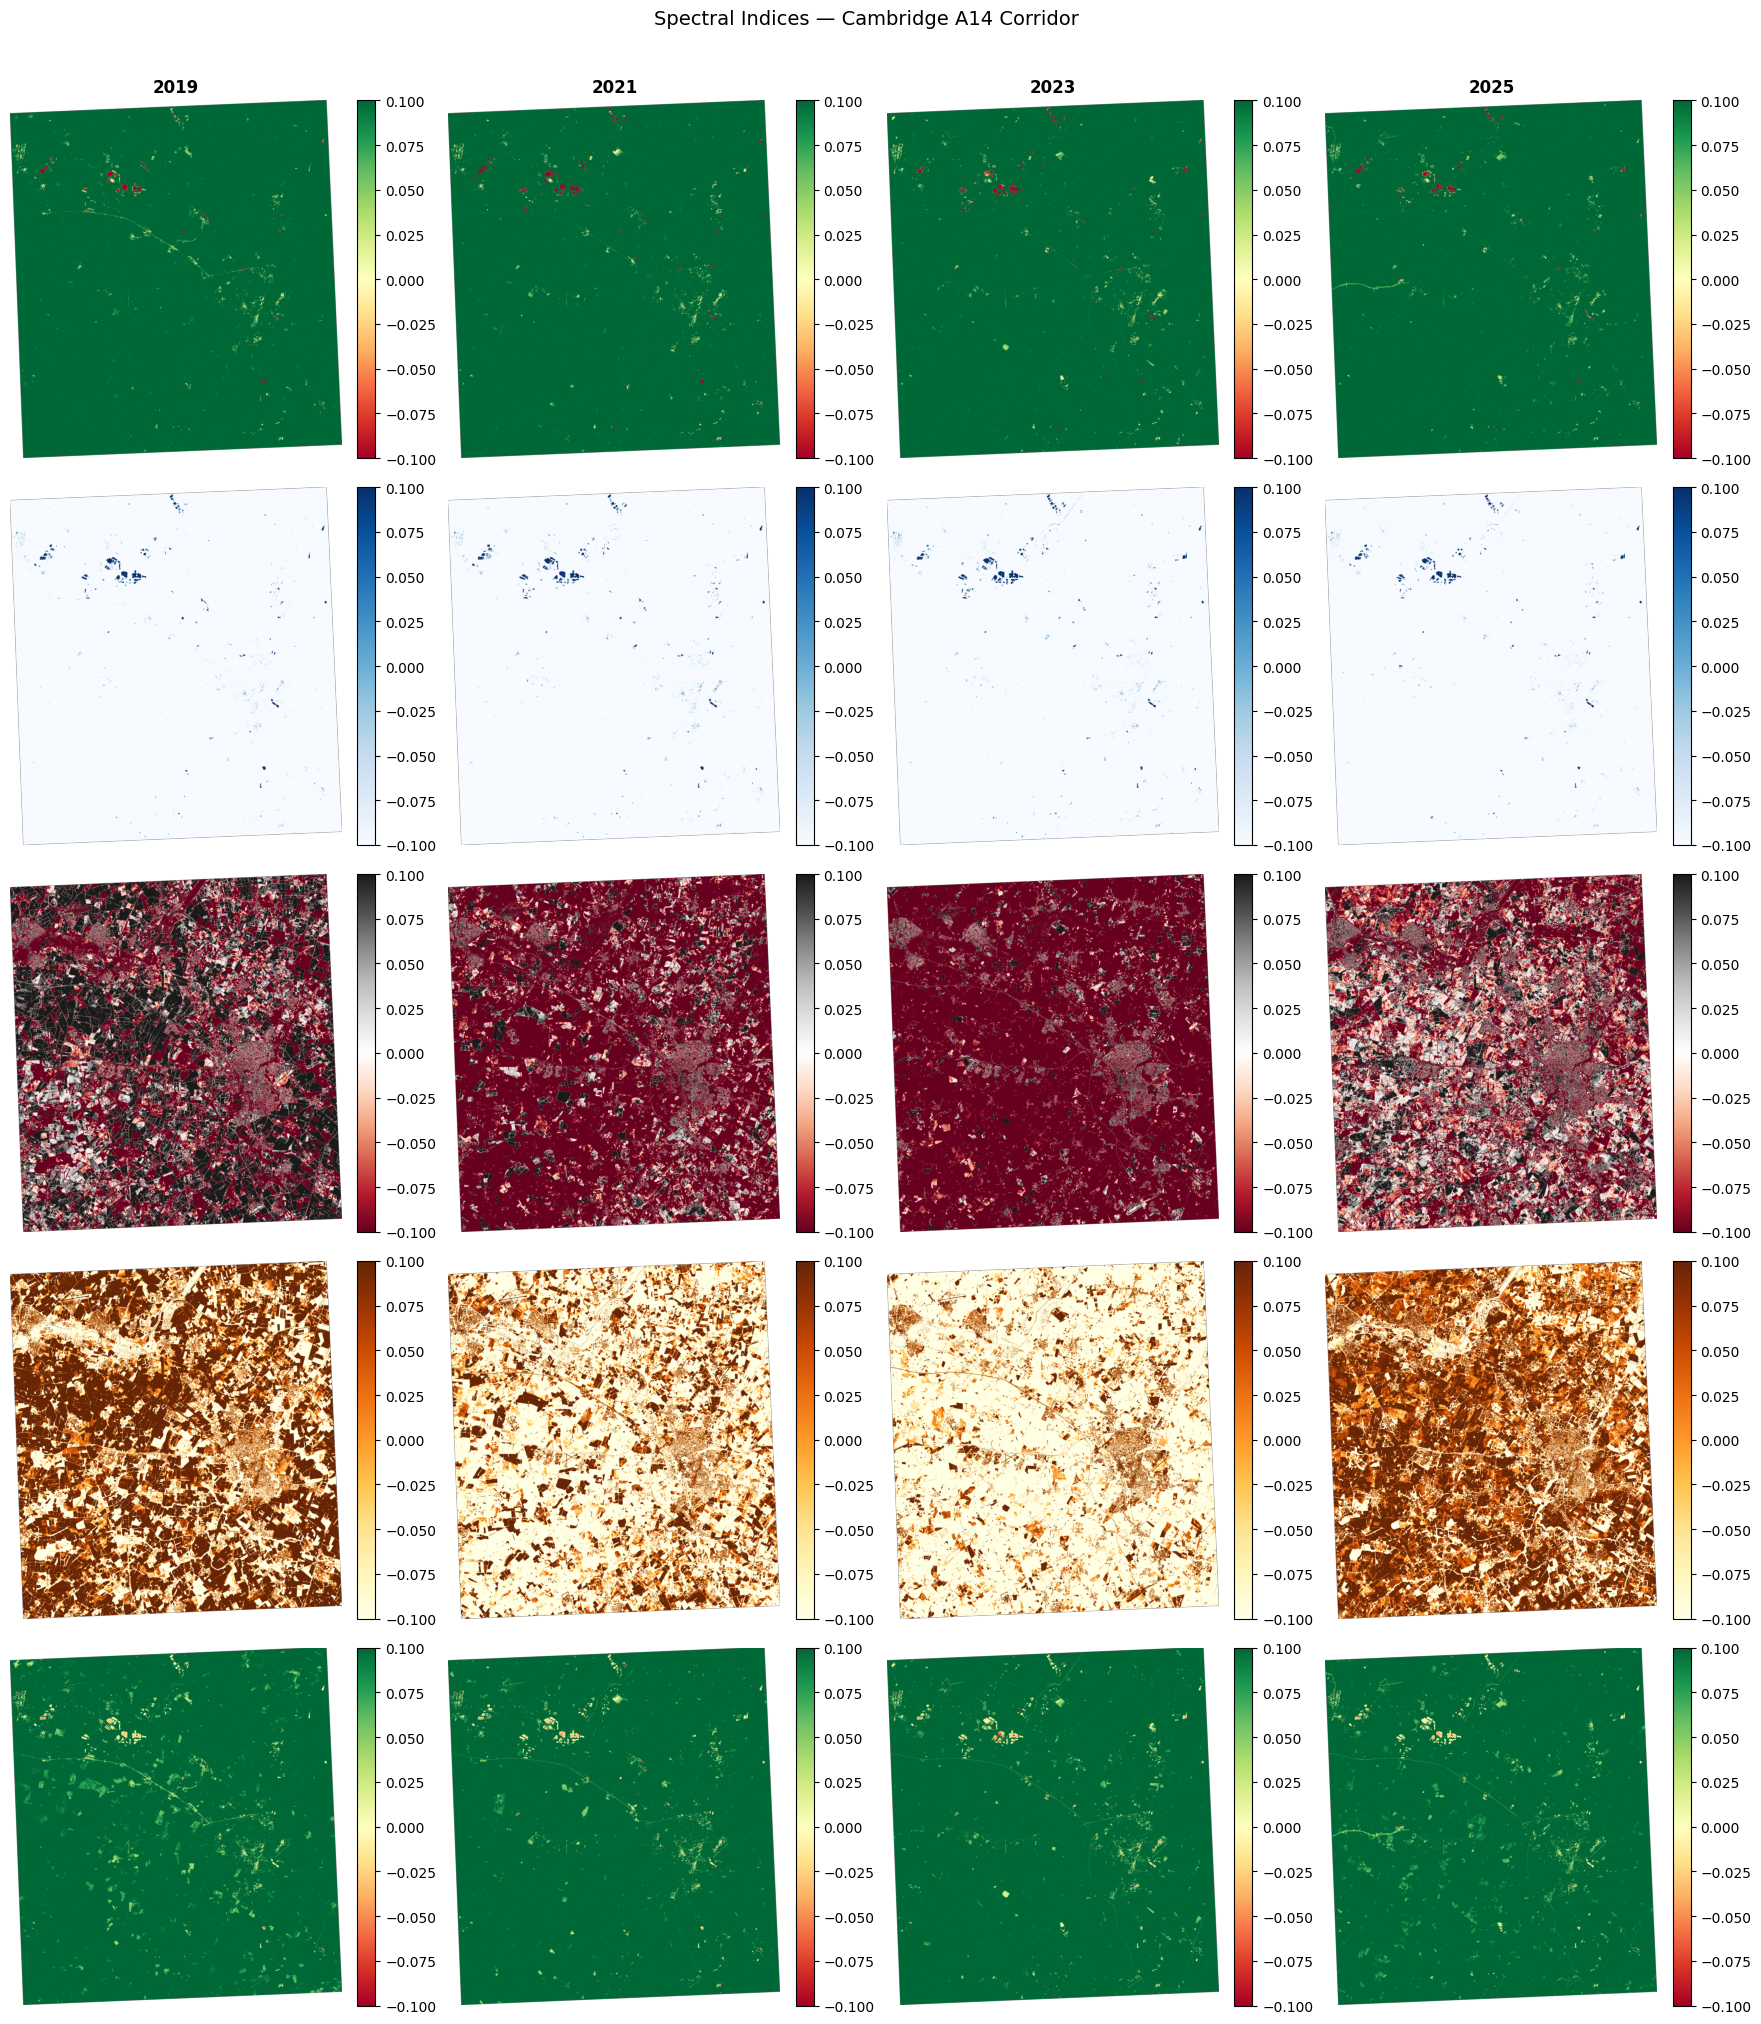

Figure saved


In [8]:
feature_names = ['NDVI', 'NDWI', 'NDBI', 'BSI', 'EVI']
feature_cmaps = ['RdYlGn', 'Blues', 'RdGy', 'YlOrBr', 'RdYlGn']
feature_idx   = [0, 1, 2, 3, 4]  # positions in the feature stack

fig, axes = plt.subplots(len(feature_names), 4, figsize=(18, 20))

for row, (name, cmap, idx) in enumerate(zip(feature_names, feature_cmaps, feature_idx)):
    for col, epoch in enumerate(epochs):
        ax = axes[row, col]
        data = feature_stacks[epoch][idx]

        # Use 2nd and 98th percentile for colour scaling to avoid outliers dominating
        vmin = np.percentile(data[data != 0], 2)
        vmax = np.percentile(data[data != 0], 98)

        im = ax.imshow(data, cmap=cmap, vmin=vmin, vmax=vmax)
        plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)

        if row == 0:
            ax.set_title(epoch, fontsize=12, fontweight='bold')
        if col == 0:
            ax.set_ylabel(name, fontsize=11, fontweight='bold')

        ax.axis('off')

plt.suptitle('Spectral Indices — Cambridge A14 Corridor', fontsize=14, y=1.01)
plt.tight_layout()
plt.savefig(os.path.join(features_path, 'spectral_indices.png'),
            dpi=150, bbox_inches='tight')
plt.show()
print("Figure saved")

Confirm all feature stack files are saved and print a summary of the value ranges per feature. Checking for NaN or infinite values now saves debugging time later.


In [9]:
feature_labels = [
    'NDVI', 'NDWI', 'NDBI', 'BSI', 'EVI',
    'B2', 'B3', 'B4', 'B8', 'B11',
    'VV', 'VH', 'VH/VV',
    'GLCM contrast', 'GLCM homogeneity'
]

print("=== FEATURE STACK SUMMARY ===\n")

for epoch in epochs:
    path = os.path.join(features_path, f'features_{epoch}.tif')

    with rasterio.open(path) as src:
        data = src.read()

    print(f"Epoch {epoch} — shape: {data.shape}")

    nan_count = np.sum(~np.isfinite(data))
    if nan_count > 0:
        print(f"  WARNING: {nan_count} non-finite values found")
    else:
        print(f"  No NaN or infinite values")

    for i, label in enumerate(feature_labels):
        band = data[i]
        valid = band[np.isfinite(band)]
        print(f"  {label:20s}: min={valid.min():.3f}  max={valid.max():.3f}  mean={valid.mean():.3f}")
    print()

print("Feature engineering complete. Ready for notebook 03 — labelling.")

=== FEATURE STACK SUMMARY ===

Epoch 2019 — shape: (15, 3465, 3212)
  NDVI                : min=-0.719  max=0.940  mean=0.435
  NDWI                : min=-0.881  max=0.837  mean=-0.474
  NDBI                : min=-0.770  max=0.742  mean=-0.010
  BSI                 : min=-0.588  max=0.572  mean=0.033
  EVI                 : min=-5.000  max=5.000  mean=0.309
  B2                  : min=0.014  max=0.920  mean=0.067
  B3                  : min=0.014  max=1.035  mean=0.094
  B4                  : min=0.009  max=1.032  mean=0.107
  B8                  : min=0.003  max=1.138  mean=0.278
  B11                 : min=0.008  max=1.005  mean=0.268
  VV                  : min=0.003  max=1.000  mean=0.150
  VH                  : min=0.000  max=1.000  mean=0.092
  VH/VV               : min=0.003  max=5.000  mean=0.270
  GLCM contrast       : min=0.000  max=0.000  mean=0.000
  GLCM homogeneity    : min=1.000  max=1.000  mean=1.000

Epoch 2021 — shape: (15, 3465, 3212)
  NDVI                : min=-0.9